## Data pooling and label definition
Pool the motif-level outputs across sonatas, then define the final transformation family set used in the CRF analysis.

In [ ]:
########################################################################
# Concatenate selected sonatas and keep sonata_id / globally unique segment_id
########################################################################
from pathlib import Path
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import random

random.seed(42)
np.random.seed(42)
np.set_printoptions(precision=5, suppress=True)


########################################################################
# Choose which period to load: 'early', 'middle', 'late', or 'all'
########################################################################
LOAD_PERIOD = "early"  # <-- change this to 'early', 'middle', 'late', or 'all'

period_dict = {
    "early":  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 19, 20],
    "middle": [12, 13, 14, 15, 16, 17, 18, 21, 22, 23, 24, 25, 26, 27],
    "late":   [28, 29, 30, 31, 32],
    "all":    list(range(1, 33))
}

# Filter sonata IDs
requested_ids = period_dict[LOAD_PERIOD]


########################################################################
# 1. Paths
########################################################################
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

DATA_DIR  = ROOT / "data" / "processed" / "transformations_with_motifs"
DIR_FEAT  = DATA_DIR / "motif_features"
DIR_META  = DATA_DIR / "motif_metadata"
DIR_LABEL = DATA_DIR / "sentence_label_matrix"

########################################################################
# 2. Discover all sonata IDs in the directory
########################################################################
feat_files = sorted(glob.glob(str(DIR_FEAT / "sonata*_motif_features.feather")))
if not feat_files:
    raise RuntimeError("No sonata*_motif_features.feather files found")

re_sid = re.compile(r"sonata(\d+)_")   # pulls the digits
sonata_ids = sorted(int(re_sid.search(Path(f).name).group(1)) for f in feat_files)

pad_width = len(re_sid.search(Path(feat_files[0]).name).group(1))
base_fmt  = f"sonata{{:0{pad_width}d}}_"   # e.g. "sonata01_"

print(f"• Found {len(sonata_ids)} sonatas   (file zero-padding width = {pad_width})")


########################################################################
# 3. Concatenate
########################################################################
features_all, metadata_all, label_blocks = [], [], []

for sid in sonata_ids:
    if sid not in requested_ids:
        continue

    base = base_fmt.format(sid)               # file stem
    tag  = f"s{sid:0{pad_width}d}"            # e.g. "s01", "s27"

    f_feat = DIR_FEAT / f"{base}motif_features.feather"
    f_meta = DIR_META / f"{base}motif_metadata.feather"
    f_lab  = DIR_LABEL / f"{base}sentence_label_matrix.npy"

    feat = pd.read_feather(f_feat)
    meta = pd.read_feather(f_meta)
    lab  = np.load(f_lab).astype(float)       # (N_motifs × Q)

    # -- add a sonata_id column so we can group later ------------------
    feat["sonata_id"] = sid
    meta["sonata_id"] = sid

    # -- make segment_id globally unique ------------------------------
    meta["segment_id"] = tag + "_" + meta["segment_id"].astype(str)
    if "segment_id" in feat.columns:
        feat["segment_id"] = tag + "_" + feat["segment_id"].astype(str)

    features_all.append(feat)
    metadata_all.append(meta)
    label_blocks.append(lab)

    print(f"  · sonata {sid:<3d} : {len(feat):5d} motifs   Q = {lab.shape[1]}")

########################################################################
# 4. Final pooled objects
########################################################################
motif_features        = pd.concat(features_all, ignore_index=True)
motif_metadata        = pd.concat(metadata_all, ignore_index=True)
sentence_label_matrix = np.vstack(label_blocks)

print("\n=== CONCATENATION COMPLETE ===")
print(f"  total motifs : {sentence_label_matrix.shape[0]}")
print(f"  total segments: {motif_metadata['segment_id'].nunique()}")
print(f"  total labels : {sentence_label_matrix.shape[1]}")
print("  motif_features.shape :", motif_features.shape)
print("  motif_metadata.shape :", motif_metadata.shape)

• Found 32 sonatas   (file zero-padding width = 2)
  · sonata 1   :   164 motifs   Q = 9
  · sonata 2   :   148 motifs   Q = 9
  · sonata 3   :   190 motifs   Q = 9
  · sonata 4   :   289 motifs   Q = 9
  · sonata 5   :   142 motifs   Q = 9
  · sonata 6   :   125 motifs   Q = 9
  · sonata 7   :   128 motifs   Q = 9
  · sonata 8   :   139 motifs   Q = 9
  · sonata 9   :   126 motifs   Q = 9
  · sonata 10  :   138 motifs   Q = 9
  · sonata 11  :   175 motifs   Q = 9
  · sonata 19  :    80 motifs   Q = 9
  · sonata 20  :   109 motifs   Q = 9

=== CONCATENATION COMPLETE ===
  total motifs : 1953
  total segments: 242
  total labels : 9
  motif_features.shape : (1953, 14)
  motif_metadata.shape : (1953, 4)


In [45]:
# Define final transformation families by merging contour_inversion
# and interval_grammer into a single symmetry label
TRANSFORMATION_FAMILIES = [
    "identity", "contour", "salient_leap", "rhythm",
    "contour_inversion", "interval_grammer", "note_edit",
    "harmony", "intervalic"
]

# Names of the two source labels
label_A = "contour_inversion"
label_B = "interval_grammer"

# Verify they exist
if label_A not in TRANSFORMATION_FAMILIES:
    raise ValueError(f"{label_A} not found in TRANSFORMATION_FAMILIES")

if label_B not in TRANSFORMATION_FAMILIES:
    raise ValueError(f"{label_B} not found in TRANSFORMATION_FAMILIES")

# Column indices
iA = TRANSFORMATION_FAMILIES.index(label_A)
iB = TRANSFORMATION_FAMILIES.index(label_B)

# Create the new column: OR of the two
symmetry_col = np.maximum(sentence_label_matrix[:, iA],
                          sentence_label_matrix[:, iB])

# Append the new column
sentence_label_matrix = np.column_stack([sentence_label_matrix, symmetry_col])

# Add the new label name
TRANSFORMATION_FAMILIES.append("symmetry")

print("Added new label 'symmetry'")
print("New shape:", sentence_label_matrix.shape)


# Remove the original component labels after constructing symmetry
to_drop = ["contour_inversion", "interval_grammer"]

for label in to_drop:
    if label in TRANSFORMATION_FAMILIES:
        idx = TRANSFORMATION_FAMILIES.index(label)
        sentence_label_matrix = np.delete(sentence_label_matrix, idx, axis=1)
        TRANSFORMATION_FAMILIES.pop(idx)



Added new label 'symmetry'
New shape: (1953, 10)


## Descriptive statistics and effective sample size
Summarize the prevalence of the final transformation families and evaluate segment-level effective sample sizes for pairwise label effects.

In [46]:
# Label prevalence summary for the final transformation family set
total_motifs = sentence_label_matrix.shape[0]

label_counts = sentence_label_matrix.sum(axis=0)
label_freqs = label_counts / total_motifs

summary_df = pd.DataFrame({
    "label": TRANSFORMATION_FAMILIES,
    "count": label_counts,
    "frequency": label_freqs
})

print(f"Total motifs: {total_motifs}")
print(summary_df)

Total motifs: 1953
          label  count  frequency
0      identity  109.0   0.055812
1       contour  307.0   0.157194
2  salient_leap  447.0   0.228879
3        rhythm  263.0   0.134665
4     note_edit  757.0   0.387609
5       harmony  215.0   0.110087
6    intervalic  377.0   0.193036
7      symmetry   99.0   0.050691


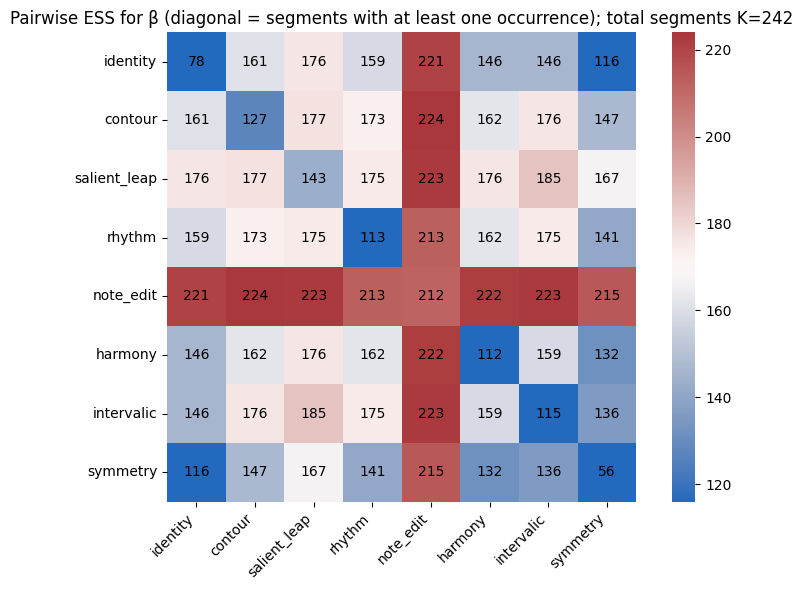

         label_q       label_r  ESS_pairs  suggested_df_t   band
0        contour       contour        127             126  green
1        contour       harmony        162             161  green
2        contour    intervalic        176             175  green
3        contour     note_edit        224             223  green
4        contour        rhythm        173             172  green
5        contour  salient_leap        177             176  green
6        contour      symmetry        147             146  green
7        harmony       harmony        112             111  green
8        harmony    intervalic        159             158  green
9        harmony      symmetry        132             131  green
10      identity       contour        161             160  green
11      identity       harmony        146             145  green
12      identity      identity         78              77  green
13      identity    intervalic        146             145  green
14      identity     note

In [47]:
# Effective sample size (ESS) diagnostics for pairwise beta parameters
# under the final transformation family set

segment2indices = motif_metadata.groupby("segment_id").groups
labels = ["identity","contour", "salient_leap", "rhythm", "note_edit", "harmony", "intervalic", "symmetry"]

# Build per-segment presence and counts
seg_ids = list(segment2indices.keys())
K = len(seg_ids)
Q = sentence_label_matrix.shape[1]

any_active = np.zeros((K, Q), dtype=bool)
count_active = np.zeros((K, Q), dtype=int)
for k, seg in enumerate(seg_ids):
    idx = list(segment2indices[seg])
    seg_labels = sentence_label_matrix[idx, :]
    any_active[k, :]   = seg_labels.any(axis=0)
    count_active[k, :] = seg_labels.sum(axis=0)

# Off-diagonal ESS: segments with q OR r
K_any = (any_active[:, :, None] | any_active[:, None, :]).sum(axis=0)  # (Q x Q)

# Diagonal ESS for β_{qq}: segments with >=1 occurrence of q
K_diag_1plus = (count_active >= 1).sum(axis=0)

# Build final ESS matrix for β: off-diagonal = K_any; diagonal = K_diag(1+)
K_beta = K_any.copy()
np.fill_diagonal(K_beta, K_diag_1plus)

# Heatmap (show diagonal; scale from off-diagonal to keep contrast)
M = K_beta.astype(float)
mask_off = ~np.eye(Q, dtype=bool)
vmin = np.nanmin(M[mask_off])
vmax = np.nanmax(M[mask_off])

plt.figure(figsize=(8,6))
ax = sns.heatmap(pd.DataFrame(M, index=labels, columns=labels),
                 cmap="vlag", vmin=vmin, vmax=vmax, square=True, cbar=True, annot=False)
# annotate integers
for i in range(Q):
    for j in range(Q):
        ax.text(j+0.5, i+0.5, f"{int(M[i,j])}", ha="center", va="center", color="black")
ax.set_title(f"Pairwise ESS for β (diagonal = segments with at least one occurrence); total segments K={K}")
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_yticklabels(labels, rotation=0)
plt.tight_layout(); plt.show()

# Per-pair table with suggested df for t-cutoffs from these ESS counts
rows = []
for q in range(Q):
    for r in range(q, Q):  # include diagonal
        ess = int(K_diag_1plus[q]) if q == r else int(K_any[q, r])
        rows.append({
            "label_q": labels[q], "label_r": labels[r],
            "ESS_pairs": ess,
            "suggested_df_t": max(1, ess - 1),
            "band": ("red" if ess < 20 else "yellow" if ess < 50 else "green")
        })
ess_pairs = pd.DataFrame(rows).sort_values(["label_q","label_r"]).reset_index(drop=True)
print(ess_pairs)


## CRF construction and model fitting

In [ ]:
# ============================================================
# Imports
# ============================================================
import numpy as np
import scipy.sparse as sp
from scipy.sparse import csr_matrix
from scipy.special import expit
from scipy.optimize import minimize
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.special import softplus


# ============================================================
# Construct segment-wise label matrices, standardized feature matrices,
# and Gaussian-decay adjacency matrices for the CRF
# ============================================================

################################################################
# Y: one sparse binary label matrix per segment
################################################################
segment_groups = motif_metadata.groupby("segment_id", sort=False)

Y_dict_sparse = {}
row0 = 0
for sid, grp in segment_groups:
    n   = len(grp)
    Y_seg = sentence_label_matrix[row0:row0+n]
    Y_dict_sparse[sid] = csr_matrix(Y_seg.astype(np.float64))
    row0 += n

################################################################
# X – numeric features  +  bias (intercept)
################################################################
non_num = ["segment_id", "motif_class", "onset", "sonata_id"]
num_cols = [c for c in motif_features.columns if c not in non_num]

# Global z-score standardization across all pooled motifs
X_num = motif_features[num_cols].astype("float64")

mu = X_num.mean()                        # Series (len = |num_cols|)
sd = X_num.std(ddof=0).replace(0, 1.0)   # avoid div-by-zero
X_num = (X_num - mu) / sd                

X_full = X_num
X_full["bias"] = 1.0

# Build one feature matrix per segment
segment_groups = motif_metadata.groupby("segment_id", sort=False)
X_dict = {
    sid: X_full.loc[grp.index].to_numpy(dtype=np.float64)
    for sid, grp in segment_groups
}

D = X_full.shape[1]


################################################################
# A: one symmetrically normalized adjacency matrix per segment
################################################################
def sym_normalise_csr(A):
    rs = np.asarray(A.sum(1)).ravel()
    scale = np.divide(1.0, np.sqrt(rs), out=np.zeros_like(rs), where=rs > 0)
    D_half = sp.diags(scale)
    return D_half @ A @ D_half

# Gaussian-decay positional graph parameters
sigma = 1.0
prune_thresh = 1e-5

A_dict = {}
for sid, grp in segment_groups:
    n = len(grp)
    if n == 1:                                  # singleton motif
        A_dict[sid] = csr_matrix((1,1), dtype=np.float64)
        continue

    G = nx.Graph()
    for i in range(n):
        for j in range(i+1, n):
            offset = j - i
            w = np.exp(-(offset ** 2) / (sigma ** 2))

            if w >= prune_thresh:
                G.add_edge(i, j, weight=w)

    A_dict[sid] = sym_normalise_csr(
        nx.to_scipy_sparse_array(G, nodelist=range(n),
                                 weight="weight", dtype=np.float64, format="csr")
    )


# ============================================================
# Problem dimensions, gauge masks, and parameter packing
# ============================================================
Q = sentence_label_matrix.shape[1]
D = X_full.shape[1]          
_TRIU = np.triu_indices(Q, k=0)

# ------------------------------------------------------------
# Row masks for numeric feature effects
# ------------------------------------------------------------
D_NUM = len(num_cols)               # number of numeric features
is_num = np.zeros(D, dtype=bool)    # shape (D,)
is_num[:D_NUM] = True               # mark numeric rows True

BIAS_ROW = D - 1 if 'bias' in X_full.columns else None


# Map each segment_id to the corresponding motif rows
segment2indices = motif_metadata.groupby("segment_id").groups

# Initialize binary matrix for segment-level label presence
S = len(segment2indices)
Q = sentence_label_matrix.shape[1]
segment_label_matrix = np.zeros((S, Q), dtype=bool)

for seg_idx, indices in enumerate(segment2indices.values()):
    seg_Y = sentence_label_matrix[list(indices)]         # (motifs_in_seg, Q)
    segment_label_matrix[seg_idx] = seg_Y.any(axis=0)    # 1 if label present in any motif in the segment

# Define the structural beta gauge from segment-level label co-occurrence
cooccur = (segment_label_matrix.T @ segment_label_matrix) > 0  # shape: (Q, Q)
PAIRWISE_GAUGE = cooccur  # includes diagonal

# ------------------------------------------------------------
# Gauge-constrained parameter packing and unpacking
# ------------------------------------------------------------
def encode_theta(alpha, beta):
    a = alpha.copy()
    a[is_num] -= a[is_num].mean(axis=0, keepdims=True)   # numeric rows only
    b = 0.5*(beta + beta.T)
    b -= b.mean(axis=1, keepdims=True) + b.mean(axis=0, keepdims=True) - b.mean()
    b[~PAIRWISE_GAUGE] = 0.0  # zero-out unsupported beta entries
    return np.concatenate([a.ravel(), b[_TRIU]])

def decode_theta(theta):
    alpha = theta[:D*Q].reshape(D, Q)
    beta  = np.zeros((Q, Q))
    beta[_TRIU] = theta[D*Q:]
    beta = beta + beta.T
    beta[np.diag_indices(Q)] /= 2  # prevent doubling diagonal values
    beta -= beta.mean(axis=1, keepdims=True) + beta.mean(axis=0, keepdims=True) - beta.mean()
    beta[~PAIRWISE_GAUGE] = 0.0  # enforce structural zero constraint
    alpha[is_num] -= alpha[is_num].mean(axis=0, keepdims=True)  # same gauge
    return alpha, beta

# ------------------------------------------------------------
# Ridge regularization parameters
# ------------------------------------------------------------
n_segments = motif_metadata['segment_id'].nunique()
lam_a, lam_b = 1e-3 +0*(1/ n_segments), 1e-3 +0*(1/ n_segments)

## Nested CRF fits and raw composite likelihood ratio comparisons

Fit the four nested pseudo-likelihood models (I, A, B, AB) and compute the corresponding raw composite likelihood ratio statistics. The full model `AB` is the main fitted model used in the subsequent inference.

In [ ]:
# ==========================================
# Fit nested pseudo-likelihood models and compute raw CLR statistics
# ==========================================

# ---------- shared core (same gauges as your pseudo_loss_and_grad) ----------
def core_loss_grad(alpha, beta, *, Y_input=None, A_input=None, X_input=None, S_input=None):
    Y_used = Y_input or Y_dict_sparse
    A_used = A_input or A_dict
    X_used = X_input or X_dict

    nll, g_a, g_b = 0.0, np.zeros_like(alpha), np.zeros_like(beta)
    for sid in Y_used:
        Y = Y_used[sid].toarray()
        A = A_used[sid]
        X = X_used[sid]
        S = S_input[sid] if S_input else A @ Y

        logits = X @ alpha + S @ beta.T
        P      = expit(logits)
        R      = P - Y

        nll += np.sum(softplus(logits) - Y * logits)
        g_a += X.T @ R
        g_b += R.T @ S

    # ridge penalties
    nll += lam_a*np.sum(alpha**2) + lam_b*np.sum(beta**2)
    g_a += 2*lam_a*alpha
    g_b += 2*lam_b*beta

    # SAME gauges/zeros as your pipeline
    g_b  = 0.5*(g_b + g_b.T)
    g_b[~PAIRWISE_GAUGE] = 0.0
    g_a[is_num] -= g_a[is_num].mean(axis=0, keepdims=True)

    return nll, g_a, g_b

def make_loss_grad(encode, decode, *,
                   Y_override=None, A_override=None, X_override=None, S_override=None):
    """
    Build a loss+grad callable for scipy.minimize.
    Optional *_override arguments let you supply permuted data
    (e.g., X_override or S_override) during permutation tests.
    """
    def f(theta_vec):
        alpha, beta = decode(theta_vec)
        nll, g_a, g_b = core_loss_grad(
            alpha, beta,
            Y_input=Y_override,
            A_input=A_override,
            X_input=X_override,
            S_input=S_override
        )
        return nll, encode(g_a, g_b)
    return f


# ---------------- I: intercept + cluster dummies (no β) ----------------
def encode_I(alpha, beta):
    # pack only non-numeric α rows; ignore β
    return alpha[~is_num].ravel()

def decode_I(theta_vec):
    alpha = np.zeros((D, Q))
    alpha[~is_num] = theta_vec.reshape((~is_num).sum(), Q)
    # numeric-row centering gauge (no effect since numeric rows are zero)
    alpha[is_num] -= alpha[is_num].mean(axis=0, keepdims=True)
    beta  = np.zeros((Q, Q))  # β ≡ 0 in this model
    return alpha, beta

theta0_I = np.zeros((~is_num).sum() * Q)
loss_I   = make_loss_grad(encode_I, decode_I)
res_I = minimize(loss_I, theta0_I, jac=True, method="L-BFGS-B",
                 options=dict(maxiter=3000, ftol=1e-9, maxls=50))
logPL_I = -res_I.fun

# ---------------- A: all α (unary), no β ----------------
def encode_A(alpha, beta):
    a = alpha.copy()
    a[is_num] -= a[is_num].mean(axis=0, keepdims=True)  # same gauge
    return a.ravel()

def decode_A(theta_vec):
    alpha = theta_vec.reshape(D, Q)
    alpha[is_num] -= alpha[is_num].mean(axis=0, keepdims=True)
    beta  = np.zeros((Q, Q))  # β ≡ 0 in this model
    return alpha, beta

theta0_A = np.zeros(D * Q)
loss_A   = make_loss_grad(encode_A, decode_A)
res_A = minimize(loss_A, theta0_A, jac=True, method="L-BFGS-B",
                 options=dict(maxiter=10000, ftol=1e-9, maxls=50))
logPL_A = -res_A.fun

# ---------------- AB: full (α + β) — use your encode_theta/decode_theta ----------------
theta0_AB = encode_theta(np.zeros((D, Q)), np.zeros((Q, Q)))
loss_AB   = make_loss_grad(encode_theta, decode_theta)
res_AB = minimize(loss_AB, theta0_AB, jac=True, method="L-BFGS-B",
                  options=dict(maxiter=15000, ftol=1e-9, maxls=50))
logPL_AB = -res_AB.fun

# ---------------- B: I + β (numeric α fixed to 0; pack β_ut with your gauges) ----------------
q_ut, r_ut = _TRIU
mask_ut = PAIRWISE_GAUGE[q_ut, r_ut]
sel_ut  = np.where(mask_ut)[0]
p_b_free = sel_ut.size

def encode_B(alpha, beta):
    # α: same as I → pack only non-numeric rows
    a_block = alpha[~is_num].ravel()
    # β: apply SAME symmetrize/centering/structural zeros, then take allowed upper-tri
    b = 0.5*(beta + beta.T)
    b -= b.mean(axis=1, keepdims=True) + b.mean(axis=0, keepdims=True) - b.mean()
    b[~PAIRWISE_GAUGE] = 0.0
    beta_ut = b[q_ut, r_ut][sel_ut]
    return np.concatenate([a_block, beta_ut])

def decode_B(theta_vec):
    n_alpha_nonnum = (~is_num).sum() * Q
    alpha = np.zeros((D, Q))
    alpha[~is_num] = theta_vec[:n_alpha_nonnum].reshape((~is_num).sum(), Q)
    alpha[is_num] -= alpha[is_num].mean(axis=0, keepdims=True)

    beta = np.zeros((Q, Q))
    beta_ut = np.zeros_like(q_ut, dtype=float)
    beta_ut[sel_ut] = theta_vec[n_alpha_nonnum:]
    beta[q_ut, r_ut] = beta_ut
    beta = beta + beta.T
    beta[np.diag_indices(Q)] /= 2                      # ← needed here
    beta -= beta.mean(axis=1, keepdims=True) + beta.mean(axis=0, keepdims=True) - beta.mean()
    beta[~PAIRWISE_GAUGE] = 0.0
    return alpha, beta

theta0_B = np.zeros((~is_num).sum() * Q + p_b_free)
loss_B   = make_loss_grad(encode_B, decode_B)
res_B = minimize(loss_B, theta0_B, jac=True, method="L-BFGS-B",
                 options=dict(maxiter=15000, ftol=1e-9, maxls=50))
logPL_B = -res_B.fun

# ---------------- Raw CLRs (unscaled) ----------------
CLR_I_A   = 2.0 * (logPL_A  - logPL_I)   # add numeric α over I
CLR_A_AB  = 2.0 * (logPL_AB - logPL_A)   # add β over A
CLR_B_AB  = 2.0 * (logPL_AB - logPL_B)   # add numeric α given β

print("\nComposite log-PLs")
print(f"  I   (intercept+dums): {logPL_I: .3f}")
print(f"  A   (unary α only)  : {logPL_A: .3f}")
print(f"  B   (I + β)         : {logPL_B: .3f}")
print(f"  AB  (full α+β)      : {logPL_AB: .3f}")

print("\nRaw CLR (no Godambe scaling)")
print(f"  I → A   (add numeric α)   : {CLR_I_A: .3f}")
print(f"  A → AB  (add β)           : {CLR_A_AB: .3f}")
print(f"  B → AB  (add numeric α|β) : {CLR_B_AB: .3f}")



Composite log-PLs
  I   (intercept+dums): -6423.161
  A   (unary α only)  : -6184.609
  B   (I + β)         : -5855.427
  AB  (full α+β)      : -5721.162

Raw CLR (no Godambe scaling)
  I → A   (add numeric α)   :  477.104
  A → AB  (add β)           :  926.896
  B → AB  (add numeric α|β) :  268.531


## Additional model-comparison inference: Godambe-adjusted CLR

This section provides an additional inferential layer for the nested model comparisons by applying a Godambe mean-matched adjustment to the raw composite likelihood ratio statistics. These tests are supplementary to the main parameter-wise inference reported later, which is based on robust Wald confidence intervals.

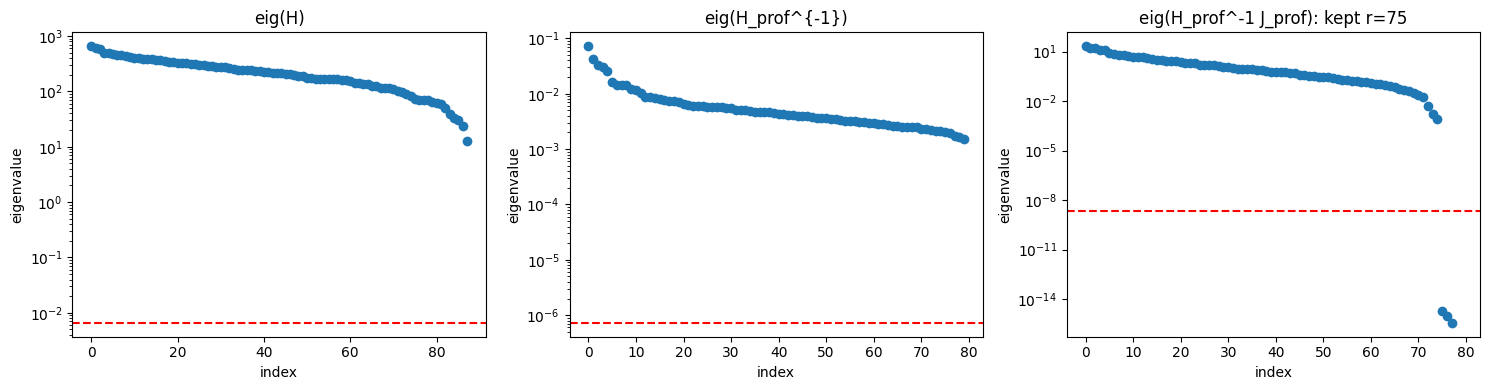

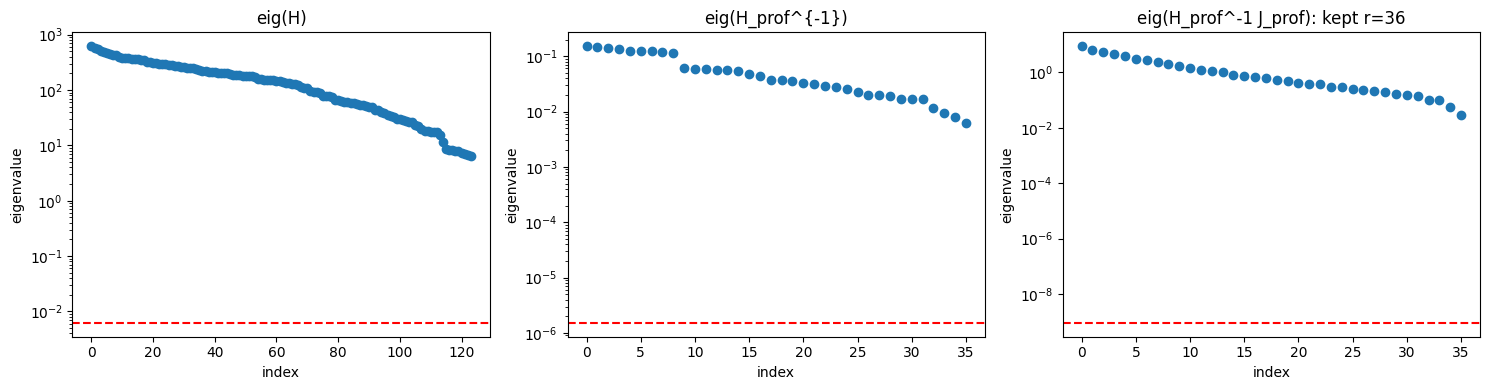

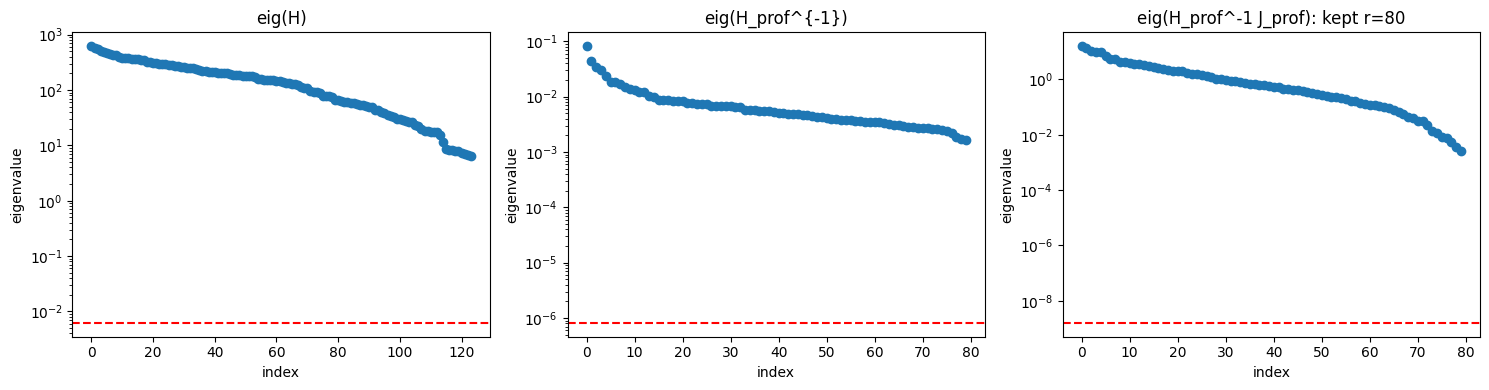


--- Godambe mean-matched CLR ---
I → A   (add α_num)    : CLR'=197.13   df=75   p=6.432e-13   (a=2.42)
A → AB  (add β)        : CLR'=623.60   df=36   p=0   (a=1.49)
B → AB  (add α_num|β)  : CLR'=148.79   df=80   p=4.808e-06   (a=1.8)

--- Holm-adjusted p-values (FWER control) for Godambe CLR ---
I → A   (add α_num)      p_raw=6.43152e-13  p_holm=1.2863e-12  |  CLR'=197.13, df=75  -> reject@α=0.05: True
A → AB  (add β)          p_raw=0  p_holm=0  |  CLR'=623.60, df=36  -> reject@α=0.05: True
B → AB  (add α_num|β)    p_raw=4.80761e-06  p_holm=4.80761e-06  |  CLR'=148.79, df=80  -> reject@α=0.05: True


In [ ]:
# ===================================================
# Supplementary Godambe mean-matched CLR for nested model comparisons
# ===================================================

import numpy as np
import scipy.stats as st

# ---- fixed numerical knobs ----
RCOND_H  = 1e-5
EIG_REL  = 1e-10
EIG_ABS  = 1e-12

# ---------- helpers ----------
def clr_profiled_via_full_inverse(H, J, idx_s, W_raw,
                                  rcond=1e-6, eig_rel=1e-10, eig_abs=1e-12,
                                  plot=True, title=""):

    idx_s = np.asarray(idx_s, int)

    # 1) Pseudoinverse of H (with eigen cutoff)
    vals_H, vecs_H = np.linalg.eigh(H)
    vmax = vals_H.max() if vals_H.size else 0.0
    cutH = rcond * (vmax if vmax > 0 else 1.0)
    inv_e = np.where(vals_H > cutH, 1.0/vals_H, 0.0)
    H_inv = (vecs_H * inv_e) @ vecs_H.T

    # 2) Godambe covariance in full space
    G = H_inv @ J @ H_inv

    # 3) Profile to the tested block s
    Hinv_ss = H_inv[np.ix_(idx_s, idx_s)]      # = H_prof^{-1}
    G_ss    = G[np.ix_(idx_s, idx_s)]          # = H_prof^{-1} J_prof H_prof^{-1}

    # 4) Build H_prof^{1/2} from H_prof^{-1}
    mu, U = np.linalg.eigh(Hinv_ss)
    mu = np.clip(mu, 0.0, None)
    mmax = mu.max() if mu.size else 0.0
    cut_mu = rcond * (mmax if mmax > 0 else 1.0)
    keep_mu = mu > cut_mu
    root_inv_mu = np.zeros_like(mu)
    root_inv_mu[keep_mu] = 1.0/np.sqrt(mu[keep_mu])
    Hhalf = (U * root_inv_mu) @ U.T

    # 5) Congruent SPD whose eigenvalues are the CLR weights
    M = Hhalf @ G_ss @ Hhalf
    M = 0.5*(M + M.T)
    lam_all, _ = np.linalg.eigh(M)
    lam_all = np.clip(lam_all, 0.0, None)
    thr = max(eig_abs, eig_rel * (lam_all.max() if lam_all.size else 0.0))
    lam = lam_all[lam_all > thr]
    r = int(lam.size)

    if r == 0:
        if plot:
            fig, ax = plt.subplots(1, 3, figsize=(15,4))
            ax[0].semilogy(np.sort(vals_H)[::-1], 'o'); ax[0].axhline(cutH, ls='--', c='r')
            ax[0].set_title("eig(H)")
            ax[1].semilogy(np.sort(mu)[::-1], 'o'); ax[1].axhline(cut_mu, ls='--', c='r')
            ax[1].set_title("eig(H_prof^{-1})")
            ax[2].semilogy([], [])
            ax[2].set_title("eig(H_prof^{-1} J_prof): none kept")
            for a in ax: a.set_xlabel("index"); a.set_ylabel("eigenvalue")
            if title: fig.suptitle(title, y=1.02)
            fig.tight_layout(); plt.show()
        return dict(a=np.nan, r=0, W_mean=np.nan, p_mean=np.nan)

    # 6) Mean-match scaling
    a = lam.mean()
    W_mean = W_raw / a
    p_mean = 1.0 - st.chi2.cdf(W_mean, df=r)

    if plot:
        fig, ax = plt.subplots(1, 3, figsize=(15,4))
        ax[0].semilogy(np.sort(vals_H)[::-1], 'o'); ax[0].axhline(cutH, ls='--', c='r')
        ax[0].set_title("eig(H)")
        ax[1].semilogy(np.sort(mu)[::-1], 'o'); ax[1].axhline(cut_mu, ls='--', c='r')
        ax[1].set_title("eig(H_prof^{-1})")
        ax[2].semilogy(np.sort(lam_all)[::-1], 'o'); ax[2].axhline(thr, ls='--', c='r')
        ax[2].set_title(f"eig(H_prof^{-1} J_prof): kept r={r}")
        for a_ in ax: a_.set_xlabel("index"); a_.set_ylabel("eigenvalue")
        if title: fig.suptitle(title, y=1.02)
        fig.tight_layout(); plt.show()

    return dict(a=a, r=r, W_mean=W_mean, p_mean=p_mean)

# ---------- indices ----------
p_a = D * Q
q_ut, r_ut = _TRIU
mask_ut = PAIRWISE_GAUGE[q_ut, r_ut]
sel_ut  = np.where(mask_ut)[0]
p_b_free = sel_ut.size

row_idx_num  = np.flatnonzero(is_num)
idx_alpha_num = (row_idx_num[:, None] * Q + np.arange(Q)[None, :]).ravel()
idx_beta      = p_a + sel_ut   # β position in packed (α | β_ut[sel_ut]) space

# ---------- H,J for UNARY fit in α-space ONLY (for I→A) ----------
alpha_u, _ = decode_A(res_A.x)

H_u = np.zeros((p_a, p_a))
scores_alpha = []

for sid in Y_dict_sparse:
    Y = Y_dict_sparse[sid].toarray()
    X = X_dict[sid]

    logits = X @ alpha_u
    P = 1.0 / (1.0 + np.exp(-logits))
    R = P - Y
    W = P * (1.0 - P)

    # α–α curvature (block-diagonal over labels)
    for q in range(Q):
        w = W[:, q][:, None]
        H_u[q*D:(q+1)*D, q*D:(q+1)*D] += (w * X).T @ X

    # α score with SAME gauge
    g_a_seg = X.T @ R
    g_a_seg[is_num] -= g_a_seg[is_num].mean(axis=0, keepdims=True)
    scores_alpha.append(g_a_seg.ravel())

H_u += 2.0 * lam_a * np.eye(p_a)
scores_u_alpha = np.vstack(scores_alpha)
J_u_alpha = scores_u_alpha.T @ scores_u_alpha

# ---------- H,J for FULL fit in (α | β_ut[sel_ut]) packed space (for A→AB, B→AB) ----------
alpha_hat, beta_hat = decode_theta(res_AB.x)

H_aa  = np.zeros((p_a, p_a))
H_abF = np.zeros((p_a, Q*Q))
H_bbF = np.zeros((Q, Q))
scores_full = []

for sid in Y_dict_sparse:
    Y = Y_dict_sparse[sid].toarray()
    X = X_dict[sid]
    S = A_dict[sid] @ Y

    logits = X @ alpha_hat + S @ beta_hat.T
    P  = 1.0 / (1.0 + np.exp(-logits))
    R  = P - Y
    W  = P * (1.0 - P)

    # α–α
    for q in range(Q):
        w = W[:, q][:, None]
        H_aa[q*D:(q+1)*D, q*D:(q+1)*D] += (w * X).T @ X

    # α–β (full; slice later)
    for q in range(Q):
        w = W[:, q][:, None]
        H_abF[q*D:(q+1)*D, q*Q:(q+1)*Q] += (w * X).T @ S

    # β–β
    H_bbF += S.T @ (W * S)

    # segment scores in SAME packing/gauges as encoders
    g_a_seg = X.T @ R
    g_b_seg = R.T @ S
    g_b_seg = 0.5*(g_b_seg + g_b_seg.T)
    g_b_seg[~PAIRWISE_GAUGE] = 0.0
    g_a_seg[is_num] -= g_a_seg[is_num].mean(axis=0, keepdims=True)

    g_beta_ut = g_b_seg[q_ut, r_ut][sel_ut]  # keep only allowed β_ut
    scores_full.append(np.hstack([g_a_seg.ravel(), g_beta_ut]))

# ridge
H_aa  += 2.0 * lam_a * np.eye(p_a)
H_bbF += 2.0 * lam_b * np.eye(Q)

# map β–β and α–β to the packed β_ut subset
H_bb_packed = np.zeros((p_b_free, p_b_free))
for q in range(Q):
    sel_q_all = np.where(q_ut == q)[0]
    sel_q = np.intersect1d(sel_q_all, sel_ut, assume_unique=False)
    if sel_q.size == 0:
        continue
    rr = r_ut[sel_q]
    colpos = np.searchsorted(sel_ut, sel_q)
    H_bb_packed[np.ix_(colpos, colpos)] = H_bbF[np.ix_(rr, rr)]

packed_cols_full = np.arange(Q*Q).reshape(Q, Q)[_TRIU].ravel()
H_ab = H_abF[:, packed_cols_full[sel_ut]]

H_full = np.zeros((p_a + p_b_free, p_a + p_b_free))
H_full[:p_a, :p_a] = H_aa
H_full[:p_a, p_a:] = H_ab
H_full[p_a:, :p_a] = H_ab.T
H_full[p_a:, p_a:] = H_bb_packed

scores_full = np.vstack(scores_full)
J_full = scores_full.T @ scores_full

# ---------- Mean-matched CLR for the three jumps (using raw CLRs from CHUNK 1) ----------
res_I_A  = clr_profiled_via_full_inverse(H_u,   J_u_alpha, idx_alpha_num, W_raw=CLR_I_A,
                                         rcond=RCOND_H, eig_rel=EIG_REL, eig_abs=EIG_ABS)
res_A_AB = clr_profiled_via_full_inverse(H_full, J_full,   idx_beta,      W_raw=CLR_A_AB,
                                         rcond=RCOND_H, eig_rel=EIG_REL, eig_abs=EIG_ABS)
res_B_AB = clr_profiled_via_full_inverse(H_full, J_full,   idx_alpha_num, W_raw=CLR_B_AB,
                                         rcond=RCOND_H, eig_rel=EIG_REL, eig_abs=EIG_ABS)

# ---------- Report (mean-match only) ----------
def _fmt(name, res):
    print(f"{name:<22} : CLR'={res['W_mean']:.2f}   df={res['r']}   p={res['p_mean']:.4g}   (a={res['a']:.3g})")

print("\n--- Godambe mean-matched CLR ---")
_fmt("I → A   (add α_num)",   res_I_A)
_fmt("A → AB  (add β)",       res_A_AB)
_fmt("B → AB  (add α_num|β)", res_B_AB)

# ---- Holm (FWER) adjustment for Godambe mean-matched CLR p-values ----
alpha_fwer = 0.05

tests = [
    ("I → A   (add α_num)",    res_I_A['W_mean'],  int(res_I_A['r']),  float(res_I_A['p_mean'])),
    ("A → AB  (add β)",        res_A_AB['W_mean'], int(res_A_AB['r']), float(res_A_AB['p_mean'])),
    ("B → AB  (add α_num|β)",  res_B_AB['W_mean'], int(res_B_AB['r']), float(res_B_AB['p_mean'])),
]

pvals = np.array([t[3] for t in tests], dtype=float)
m = len(pvals)

# sort p's ascending, apply Holm multipliers, then cumulative max for monotonicity
order      = np.argsort(pvals)
p_sorted   = pvals[order]
holm_mult  = (m - np.arange(m)) * p_sorted
adj_sorted = np.minimum(1.0, np.maximum.accumulate(holm_mult))

# map back to original order
p_holm = np.empty_like(pvals)
p_holm[order] = adj_sorted

print("\n--- Holm-adjusted p-values (FWER control) for Godambe CLR ---")
for (name, W, df, p_raw), p_adj in zip(tests, p_holm):
    decision = p_adj <= alpha_fwer
    print(f"{name:<24} p_raw={p_raw:.6g}  p_holm={p_adj:.6g}  |  CLR'={W:.2f}, df={df}  -> reject@α={alpha_fwer}: {decision}")



## Main parameter-wise inference: robust Wald confidence intervals

Estimate robust parameter uncertainty for the full AB model using the Godambe sandwich covariance, apply a small-sample t/z rule based on effective sample size, and control multiplicity with Benjamini–Hochberg FDR.

In [ ]:
# =========================
# Robust Wald confidence intervals for the full AB model
# with small-sample t/z reference and Benjamini–Hochberg FDR correction
# =========================
import scipy.stats as st

RCOND_CI = 1e-5          # same pseudoinverse threshold used in the CLR block
THRESH_T = 50            # use t when ESS < 50, else z
BH_Q     = 0.05          # target FDR for BH stars / significance

# Full-model parameter estimates from the AB fit
alpha_hat, beta_hat = decode_theta(res_AB.x)

def stable_pinv(H, inv_rcond=RCOND_CI):
    """
    Symmetrize and compute a numerically-stable pseudoinverse via eigen-truncation.
    Eigenvalues <= inv_rcond * max_eigenvalue are dropped.
    """
    H = 0.5 * (H + H.T)
    evals, evecs = np.linalg.eigh(H)
    vmax = float(evals.max()) if evals.size else 0.0
    cut = inv_rcond * (vmax if vmax > 0 else 1.0)
    inv_e = np.where(evals > cut, 1.0 / evals, 0.0)
    return (evecs * inv_e) @ evecs.T


# Reference stars for raw p-values (BH-adjusted stars are defined below)
def _row_star(p):
    if not np.isfinite(p):
        return ''
    if p < 0.01:
        return '***'   # 99.9%
    if p < 0.05:
        return '**'    # 99.5%
    if p < 0.10:
        return '*'     # 90%
    return ''


def wald_ci_small_sample_block(theta_hat_packed, H_full, J_full, idx_block,
                               ess_vec, names=None, inv_rcond=RCOND_CI):
    """
    Block-robust Wald CIs using the full Godambe sandwich covariance,
    with per-parameter small-sample reference:
      - if ESS[i] < THRESH_T: use t_{ESS[i]-1}
      - else: use N(0,1) (z)

    CI levels produced: 90%, 95%, 99% (two-sided).
    """
    # Defensive symmetrization
    H_full = 0.5 * (H_full + H_full.T)
    J_full = 0.5 * (J_full + J_full.T)

    # Full sandwich covariance
    H_inv  = stable_pinv(H_full, inv_rcond=inv_rcond)
    G_full = H_inv @ J_full @ H_inv
    G_full = 0.5 * (G_full + G_full.T)

    cov_b  = G_full[np.ix_(idx_block, idx_block)]
    est_b  = theta_hat_packed[idx_block]
    var_b  = np.clip(np.diag(cov_b), 0.0, np.inf)
    se_b   = np.sqrt(var_b)

    rows = []
    for i in range(len(idx_block)):
        est, se = float(est_b[i]), float(se_b[i])
        ess = int(ess_vec[i])
        df  = max(1, ess - 1)
        use_t = (ess < THRESH_T)

        if se > 0 and np.isfinite(se):
            stat = est / se

            if use_t:
                pval = 2.0 * (1.0 - st.t.cdf(abs(stat), df=df))
                # two-sided quantiles: 90%, 95%, 99%
                q90 = st.t.ppf(0.95,  df=df)   # 1 - 0.10/2
                q95 = st.t.ppf(0.975, df=df)   # 1 - 0.05/2
                q99 = st.t.ppf(0.995, df=df)   # 1 - 0.01/2
                dist = f"t(df={df})"
            else:
                pval = 2.0 * (1.0 - st.norm.cdf(abs(stat)))
                q90 = st.norm.ppf(0.95)
                q95 = st.norm.ppf(0.975)
                q99 = st.norm.ppf(0.995)
                dist = "z"

            lo90, hi90 = est - q90 * se, est + q90 * se
            lo95, hi95 = est - q95 * se, est + q95 * se
            lo99, hi99 = est - q99 * se, est + q99 * se
        else:
            stat = np.nan
            pval = np.nan
            dist = "NA"
            df = np.nan
            lo90 = hi90 = lo95 = hi95 = lo99 = hi99 = np.nan

        rows.append(dict(
            estimate=est, se=se, stat=stat, p=pval, star=_row_star(pval),
            ess=ess, df_used=df, dist=dist,
            lower_90=lo90, upper_90=hi90,
            lower_95=lo95, upper_95=hi95,
            lower_99=lo99, upper_99=hi99
        ))

    out = pd.DataFrame(rows)
    if names is not None:
        out.index = names
    return out


# ----------------------------
# Packed parameter indices and readable parameter names
# ----------------------------
theta_hat_packed = np.concatenate([alpha_hat.ravel(), beta_hat[_TRIU][sel_ut]])

p_a = D * Q
idx_alpha_full = np.arange(p_a)
idx_beta       = np.arange(p_a, p_a + sel_ut.size)

label_list = ["identity", "contour","salient_leap","rhythm","note_edit","harmony","intervalic", "symmetry"]
assert Q == len(label_list), "Mismatch between Q and label names"

alpha_names = [f"{feat}_{lab}" for feat in X_full.columns for lab in label_list]
q_ut, r_ut = _TRIU
beta_names_kept = [f"{label_list[i]}_{label_list[j]}" for i, j in zip(q_ut[sel_ut], r_ut[sel_ut])]

# ----------------------------
# ESS vectors
# ----------------------------
K_total = len(segment2indices)  # total segments
ess_alpha_vec = np.full(len(idx_alpha_full), K_total, dtype=int)

pair_i = q_ut[sel_ut]
pair_j = r_ut[sel_ut]
# K_beta comes from the final ESS diagnostics computed earlier
ess_beta_vec = np.array([int(K_beta[i, j]) for (i, j) in zip(pair_i, pair_j)], dtype=int)

# ----------------------------
# Symmetrize H_full/J_full once (defensive)
# ----------------------------
H_full = 0.5 * (H_full + H_full.T)
J_full = 0.5 * (J_full + J_full.T)

# ----------------------------
# CI tables with small-sample rule (RAW p-values)
# ----------------------------
ci_alpha_ss = wald_ci_small_sample_block(theta_hat_packed, H_full, J_full, idx_alpha_full,
                                         ess_vec=ess_alpha_vec, names=alpha_names, inv_rcond=RCOND_CI)

ci_beta_ss  = wald_ci_small_sample_block(theta_hat_packed, H_full, J_full, idx_beta,
                                         ess_vec=ess_beta_vec,  names=beta_names_kept, inv_rcond=RCOND_CI)

# Color bands based on ESS thresholds, for quick inspection
def _band(ess): return "red" if ess < 20 else ("yellow" if ess < 50 else "green")
ci_beta_ss["band"]  = ci_beta_ss["ess"].map(_band)
ci_alpha_ss["band"] = ci_alpha_ss["ess"].map(_band)

# ----------------------------
# Benjamini–Hochberg FDR adjustment and significance labels
# ----------------------------
def _bh_qvalues(p_array):
    p = np.asarray(p_array, float)
    q = np.full_like(p, np.nan, dtype=float)
    mask = np.isfinite(p)
    m = int(mask.sum())
    if m == 0:
        return q
    p_clean = p[mask]
    order = np.argsort(p_clean)
    ranks = np.empty_like(order, dtype=float)
    ranks[order] = np.arange(1, m + 1, dtype=float)
    q_clean = p_clean * m / ranks
    q_sorted = q_clean[order]
    q_sorted = np.minimum.accumulate(q_sorted[::-1])[::-1]
    q_clean[order] = q_sorted
    q[mask] = np.clip(q_clean, 0.0, 1.0)
    return q

def _star_from_q(qv):
    if not np.isfinite(qv): return ''
    if qv < 0.01: return '***'   # 0.1% FDR
    if qv < 0.05: return '**'    # 0.5% FDR
    if qv < 0.10:  return '*'     # 10% FDR
    return ''

def _apply_bh(df, q_level=BH_Q):
    out = df.copy()
    out["q_bh"]    = _bh_qvalues(out["p"].values)
    out["sig_bh"]  = out["q_bh"] <= q_level
    out["star_bh"] = [ _star_from_q(v) for v in out["q_bh"].values ]
    return out

ci_alpha_bh = _apply_bh(ci_alpha_ss, q_level=BH_Q)
ci_beta_bh  = _apply_bh(ci_beta_ss,  q_level=BH_Q)

print(f"α: {ci_alpha_bh['sig_bh'].sum()} / {len(ci_alpha_bh)} BH-significant @ q={BH_Q}")
print(f"β: {ci_beta_bh['sig_bh'].sum()} / {len(ci_beta_bh)} BH-significant @ q={BH_Q}")


α: 23 / 88 BH-significant @ q=0.05
β: 20 / 36 BH-significant @ q=0.05


In [ ]:
# Extract BH-significant alpha and beta parameters
ci_alpha_sig = ci_alpha_bh[ci_alpha_bh["sig_bh"] != False]
ci_beta_sig  = ci_beta_bh[ci_beta_bh["sig_bh"] != False]

# Display
print("Significant alpha estimates:")
display(ci_alpha_sig)

print("Significant beta estimates:")
display(ci_beta_sig)


Significant alpha estimates:


,estimate,se,stat,p,star,ess,df_used,dist,lower_90,upper_90,lower_95,upper_95,lower_99,upper_99,band,q_bh,sig_bh,star_bh
secondary_chord_proportion_symmetry,0.345524,0.090611,3.813252,1.371503e-04,***,242,241,z,0.196482,0.494567,0.167929,0.523120,0.112125,0.578924,green,7.099544e-04,True,***
key_change_count_contour,-0.148237,0.033021,-4.489123,7.151702e-06,***,242,241,z,-0.202553,-0.093922,-0.212958,-0.083516,-0.233295,-0.063180,green,5.244582e-05,True,***
key_change_count_salient_leap,-0.190839,0.053542,-3.564256,3.648893e-04,***,242,241,z,-0.278908,-0.102769,-0.295780,-0.085898,-0.328754,-0.052923,green,1.783903e-03,True,***
key_change_count_rhythm,-0.237682,0.045132,-5.266342,1.391689e-07,***,242,241,z,-0.311918,-0.163446,-0.326139,-0.149224,-0.353935,-0.121429,green,1.113351e-06,True,***
key_change_count_harmony,-0.284237,0.108020,-2.631344,8.504799e-03,***,242,241,z,-0.461914,-0.106560,-0.495952,-0.072522,-0.562478,-0.005997,green,3.254010e-02,True,**
key_change_count_symmetry,-0.307504,0.017130,-17.951278,0.000000e+00,***,242,241,z,-0.335680,-0.279328,-0.341078,-0.273930,-0.351627,-0.263380,green,0.000000e+00,True,***
pitch_spread_salient_leap,0.196979,0.065371,3.013227,2.584858e-03,***,242,241,z,0.089452,0.304505,0.068853,0.325105,0.028593,0.365364,green,1.137338e-02,True,**
pitch_spread_rhythm,0.251391,0.061204,4.107458,4.000374e-05,***,242,241,z,0.150720,0.352062,0.131434,0.371348,0.093741,0.409041,green,2.346886e-04,True,***
pitch_spread_note_edit,0.270757,0.100579,2.691995,7.102595e-03,***,242,241,z,0.105320,0.436195,0.073627,0.467888,0.011684,0.529831,green,2.841038e-02,True,**
pitch_spread_symmetry,-0.140247,0.035502,-3.950457,7.800227e-05,***,242,241,z,-0.198642,-0.081852,-0.209829,-0.070666,-0.231693,-0.048801,green,4.290125e-04,True,***


Significant beta estimates:


,estimate,se,stat,p,star,ess,df_used,dist,lower_90,upper_90,lower_95,upper_95,lower_99,upper_99,band,q_bh,sig_bh,star_bh
identity_identity,2.384985,0.789117,3.022346,2.508234e-03,***,78,77,z,1.087003,3.682967,0.838344,3.931626,0.352354,4.417616,green,4.752443e-03,True,***
identity_note_edit,-0.340231,0.051585,-6.595564,4.236411e-11,***,221,220,z,-0.425081,-0.255382,-0.441335,-0.239127,-0.473105,-0.207357,green,3.050216e-10,True,***
identity_harmony,-0.541407,0.136900,-3.954776,7.660650e-05,***,146,145,z,-0.766587,-0.316227,-0.809726,-0.273089,-0.894037,-0.188777,green,1.977407e-04,True,***
identity_symmetry,-1.473155,0.119319,-12.346311,0.000000e+00,***,116,115,z,-1.669418,-1.276892,-1.707016,-1.239293,-1.780501,-1.165808,green,0.000000e+00,True,***
contour_contour,1.608381,0.305025,5.272953,1.342458e-07,***,127,126,z,1.106660,2.110103,1.010544,2.206219,0.822690,2.394073,green,4.832850e-07,True,***
contour_rhythm,-0.489193,0.127751,-3.829255,1.285317e-04,***,173,172,z,-0.699325,-0.279060,-0.739581,-0.238805,-0.818258,-0.160127,green,3.084761e-04,True,***
contour_note_edit,-0.591775,0.078362,-7.551781,4.285461e-14,***,224,223,z,-0.720669,-0.462880,-0.745362,-0.438188,-0.793623,-0.389927,green,3.856915e-13,True,***
contour_intervalic,-1.184055,0.105991,-11.171256,0.000000e+00,***,176,175,z,-1.358396,-1.009715,-1.391795,-0.976316,-1.457071,-0.911040,green,0.000000e+00,True,***
salient_leap_salient_leap,1.826901,0.332216,5.499129,3.816727e-08,***,143,142,z,1.280454,2.373348,1.175769,2.478033,0.971168,2.682634,green,1.716525e-07,True,***
salient_leap_rhythm,-0.622227,0.177935,-3.496934,4.706379e-04,***,175,174,z,-0.914904,-0.329550,-0.970974,-0.273481,-1.080558,-0.163897,green,9.966449e-04,True,***


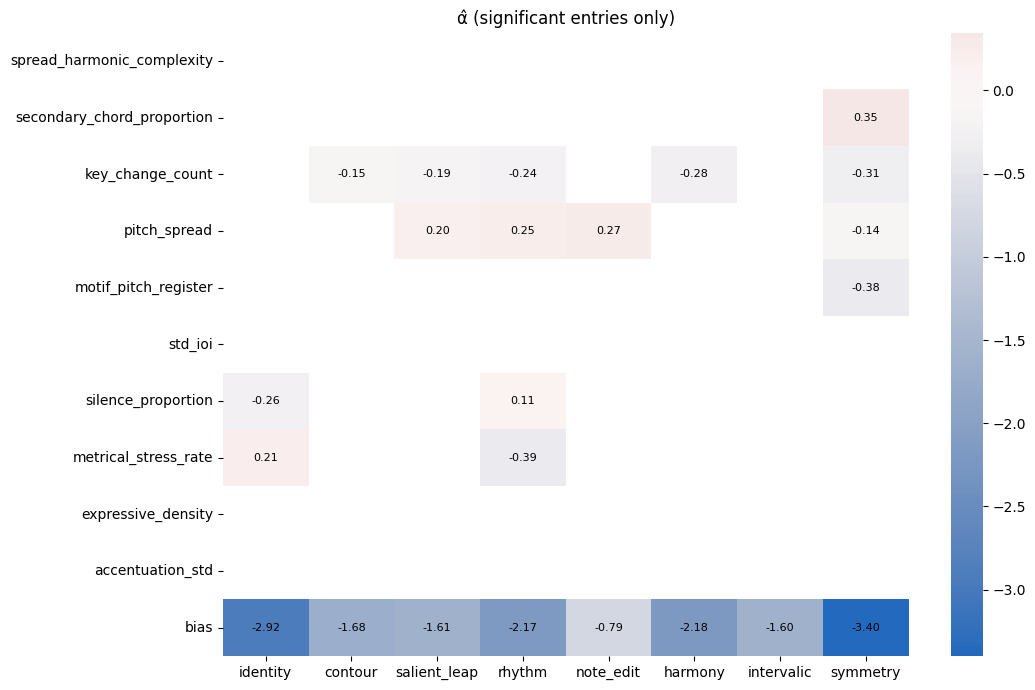

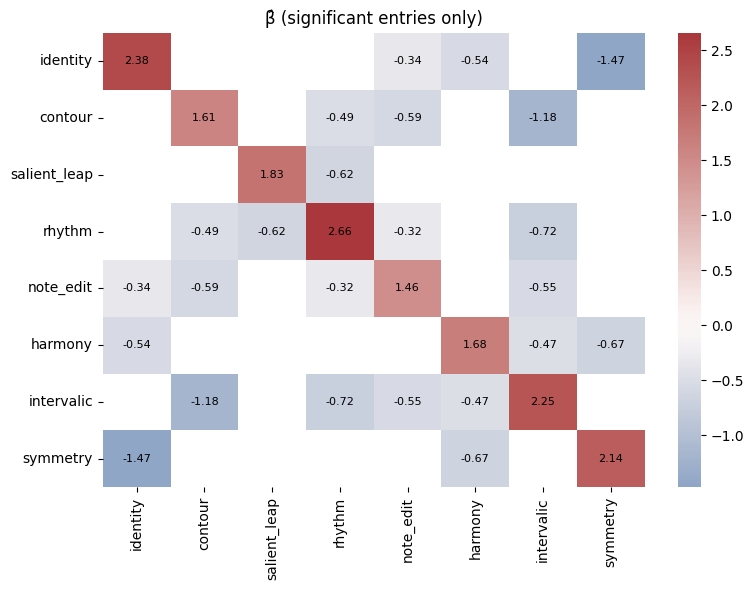

In [ ]:
# Build significant-only alpha and beta heatmaps from the BH-adjusted Wald results

# ---------------------------------------
# Map parameter names back to matrix positions
# ---------------------------------------
labels = TRANSFORMATION_FAMILIES if 'TRANSFORMATION_FAMILIES' in globals() else label_list
feat_names = list(X_full.columns)

D, Q = alpha_hat.shape
assert D == len(feat_names) and Q == len(labels)

# Alpha packing order matches alpha_hat.ravel() (row-major: feature-major then label)
alpha_names = [f"{feat}_{lab}" for feat in feat_names for lab in labels]
name_to_pos_alpha = {name: k for k, name in enumerate(alpha_names)}

# Beta kept order matches sel_ut over upper-tri pairs (q_ut, r_ut)
q_ut, r_ut = _TRIU
pair_i = q_ut[sel_ut]
pair_j = r_ut[sel_ut]
beta_names_kept = [f"{labels[i]}_{labels[j]}" for i, j in zip(pair_i, pair_j)]
name_to_pair_beta = {name: (i, j) for name, i, j in zip(beta_names_kept, pair_i, pair_j)}

# ----------------------------------------------------
# Build alpha and beta matrices that retain only BH-significant entries
# ----------------------------------------------------
# α: start with all NaN, fill only sig positions with alpha_hat values
alpha_sig = np.full_like(alpha_hat, np.nan, dtype=float)
for name in ci_alpha_bh.index:  # iterate all (we'll check star)
    if ci_alpha_bh.loc[name, "sig_bh"] == False:  # not significant
        continue
    k = name_to_pos_alpha.get(name)
    if k is None: 
        continue
    i = k // Q            # feature index
    j = k % Q             # label index
    alpha_sig[i, j] = alpha_hat[i, j]

# β: start with all NaN, fill symmetric entries only for sig kept coords
beta_sig = np.full_like(beta_hat, np.nan, dtype=float)
for name in ci_beta_bh.index:
    if ci_beta_bh.loc[name, "sig_bh"] == False:  # not significant
        continue
    ij = name_to_pair_beta.get(name)
    if ij is None:
        continue
    i, j = ij
    val = beta_hat[i, j]
    beta_sig[i, j] = val
    beta_sig[j, i] = val   # symmetric

# Optional: also hide structurally disallowed β cells (if PAIRWISE_GAUGE present)
if 'PAIRWISE_GAUGE' in globals():
    mask_false = ~PAIRWISE_GAUGE
    beta_sig = beta_sig.copy()
    beta_sig[mask_false] = np.nan

# ---------------------------------------
# Plot significant-only heatmaps
# ---------------------------------------
# α̂ heatmap (significant only)
plt.figure(figsize=(11, 7))
ax = sns.heatmap(alpha_sig, xticklabels=labels, yticklabels=feat_names,
                 center=0, cmap="vlag", cbar=True, annot=False)

# manual annotations only where not NaN
for i in range(D):
    for j in range(Q):
        val = alpha_sig[i, j]
        if np.isfinite(val):
            ax.text(j + 0.5, i + 0.5, f"{val:.2f}", ha='center', va='center',
                    color='black', fontsize=8)
plt.title("α̂ (significant entries only)")
plt.tight_layout()
plt.show()

# β̂ heatmap (significant only)
plt.figure(figsize=(8, 6))
ax = sns.heatmap(beta_sig, xticklabels=labels, yticklabels=labels,
                 center=0, cmap="vlag", cbar=True, annot=False)

for i in range(Q):
    for j in range(Q):
        val = beta_sig[i, j]
        if np.isfinite(val):
            ax.text(j + 0.5, i + 0.5, f"{val:.2f}", ha='center', va='center',
                    color='black', fontsize=8)
plt.title("β̂ (significant entries only)")
plt.tight_layout()
plt.show()


## Main model-comparison inference: permutation tests for nested CLR statistics

This section provides the main inferential comparison between the nested models by calibrating the raw composite likelihood ratio statistics with segment-wise permutation tests. The Godambe mean-matched CLR results reported earlier are supplementary and serve as an additional asymptotic approximation.

In [ ]:
# ================================================================
# Main model-comparison inference: permutation tests for the nested CLR statistics
#   - I→A  : permute numeric X rows within segment (break α_num ↔ Y)
#   - A→AB : permute S rows within segment (break the beta / graph signal)
#   - B→AB : permute numeric X rows within segment (test α_num conditional on β)
#
# Notes:
#   * These tests use the raw CLR statistics; permutation provides the calibration.
#   * The global X_dict / Y_dict_sparse / A_dict objects are not mutated.
#   * Fitted models and packing utilities from the previous sections are reused here.
# ================================================================

import numpy as np
from scipy.optimize import minimize

# ----- settings -----
B_PERM = 1000
SEED   = 12345                 # set None for non-deterministic
rng    = np.random.default_rng(SEED)

# observed raw CLRs from your CHUNK 1
CLR_obs_I_A  = CLR_I_A
CLR_obs_A_AB = CLR_A_AB
CLR_obs_B_AB = CLR_B_AB

sids = list(Y_dict_sparse.keys())
has_numeric = bool(np.sum(is_num))

# helpers: build permuted dicts
def permute_X_numeric_within_segment(X_base, rng):
    """Return a new dict with numeric columns row-permuted within each segment."""
    X_perm = {}
    for sid in sids:
        X = X_base[sid]
        if has_numeric:
            idx = rng.permutation(X.shape[0])
            Xp = X.copy()
            Xp[:, is_num] = X[idx][:, is_num]
        else:
            Xp = X  # nothing to permute
        X_perm[sid] = Xp
    return X_perm

def permute_S_rows_within_segment(Y_base, A_base, rng):
    """Return a new dict of S=A@Y with rows permuted within each segment."""
    S_perm = {}
    for sid in sids:
        Y = Y_base[sid].toarray()
        S = A_base[sid] @ Y
        idx = rng.permutation(S.shape[0])
        S_perm[sid] = S[idx, :]
    return S_perm

# storage
clr_null_I_A  = np.zeros(B_PERM)
clr_null_A_AB = np.zeros(B_PERM)
clr_null_B_AB = np.zeros(B_PERM)

# warm starts
theta_I0  = res_I.x
theta_A0  = res_A.x
theta_B0  = res_B.x
theta_AB0 = res_AB.x

for b in range(B_PERM):
    # --------- I→A null: destroy α_num signal by permuting X (segment-wise) ---------
    X_perm = permute_X_numeric_within_segment(X_dict, rng)

    # (I) intercept-only uses only non-numeric rows; refit is optional.
    # It's identical under this permutation, so reuse original logPL_I for speed.
    # If you prefer to refit, uncomment the lines below.
    LL_I_perm = logPL_I
    # loss_I_perm = make_loss_grad(encode_I, decode_I, X_override=X_perm)
    # res_I_perm  = minimize(loss_I_perm, theta_I0, jac=True, method="L-BFGS-B",
    #                        options=dict(maxiter=3000, ftol=1e-9, maxls=50))
    # LL_I_perm   = -res_I_perm.fun
    # theta_I0    = res_I_perm.x  # warm start update (optional)

    # (A) unary on permuted X
    loss_A_perm = make_loss_grad(encode_A, decode_A, X_override=X_perm)
    res_A_perm  = minimize(loss_A_perm, theta_A0, jac=True, method="L-BFGS-B",
                           options=dict(maxiter=10000, ftol=1e-9, maxls=50))
    LL_A_perm   = -res_A_perm.fun
    theta_A0    = res_A_perm.x

    clr_null_I_A[b] = 2.0 * (LL_A_perm - LL_I_perm)

    # --------- A→AB null: destroy the beta / graph signal by permuting S within segment ---------
    S_perm = permute_S_rows_within_segment(Y_dict_sparse, A_dict, rng)

    # AB with permuted S
    loss_AB_permS = make_loss_grad(encode_theta, decode_theta, S_override=S_perm)
    res_AB_permS  = minimize(loss_AB_permS, theta_AB0, jac=True, method="L-BFGS-B",
                             options=dict(maxiter=15000, ftol=1e-9, maxls=50))
    LL_AB_permS   = -res_AB_permS.fun
    theta_AB0     = res_AB_permS.x

    # unary log-lik is unaffected by S, so reuse original logPL_A (safe & faster)
    clr_null_A_AB[b] = 2.0 * (LL_AB_permS - logPL_A)

    # --------- B→AB null: test α_num | β by permuting X (segment-wise) ------------
    # Fit B (I + β) on the same X_perm
    loss_B_permX = make_loss_grad(encode_B, decode_B, X_override=X_perm)
    res_B_perm   = minimize(loss_B_permX, theta_B0, jac=True, method="L-BFGS-B",
                            options=dict(maxiter=15000, ftol=1e-9, maxls=50))
    LL_B_perm    = -res_B_perm.fun
    theta_B0     = res_B_perm.x

    # Fit AB on that same X_perm
    loss_AB_permX = make_loss_grad(encode_theta, decode_theta, X_override=X_perm)
    res_AB_permX  = minimize(loss_AB_permX, theta_AB0, jac=True, method="L-BFGS-B",
                             options=dict(maxiter=15000, ftol=1e-9, maxls=50))
    LL_AB_permX   = -res_AB_permX.fun
    theta_AB0     = res_AB_permX.x

    clr_null_B_AB[b] = 2.0 * (LL_AB_permX - LL_B_perm)

    if (b+1) % max(1, B_PERM//10) == 0:
        print(f"[perm {b+1}/{B_PERM}]")

# Empirical upper-tail permutation p-values
p_I_A  = (1 + (clr_null_I_A  >= CLR_obs_I_A ).sum())  / (1 + B_PERM)
p_A_AB = (1 + (clr_null_A_AB >= CLR_obs_A_AB).sum()) / (1 + B_PERM)
p_B_AB = (1 + (clr_null_B_AB >= CLR_obs_B_AB).sum()) / (1 + B_PERM)

print("\n--- Permutation p-values (raw CLR) ---")
print(f"I → A   : p = {p_I_A:.4g}   (obs CLR = {CLR_obs_I_A:.2f})")
print(f"A → AB  : p = {p_A_AB:.4g}  (obs CLR = {CLR_obs_A_AB:.2f})")
print(f"B → AB  : p = {p_B_AB:.4g}  (obs CLR = {CLR_obs_B_AB:.2f})")

# (Optional) keep the null vectors for plotting later:
perm_nulls = {
    "I→A":  clr_null_I_A,
    "A→AB": clr_null_A_AB,
    "B→AB": clr_null_B_AB,
}


# Holm step-down adjustment for the three permutation p-values
alpha = 0.05
labels = ["I→A (add α_num)", "A→AB (add β)", "B→AB (add α_num | β)"]
pvals  = np.array([p_I_A, p_A_AB, p_B_AB], dtype=float)

m = len(pvals)
order = np.argsort(pvals)
p_sorted = pvals[order]

# Step-down decisions
thr = alpha / (m - np.arange(m))
reject_sorted = np.zeros(m, dtype=bool)
for k in range(m):
    if p_sorted[k] <= thr[k]:
        reject_sorted[k] = True
    else:
        # stop and keep the rest as False
        break

# Adjusted p-values (Holm): cummax of (multipliers * sorted p)
raw_adj_sorted = (m - np.arange(m)) * p_sorted
holm_adj_sorted = np.minimum(1.0, np.maximum.accumulate(raw_adj_sorted))

# Map back to original order
reject = np.zeros(m, dtype=bool); reject[order] = reject_sorted
holm_p = np.empty(m);             holm_p[order] = holm_adj_sorted

# Pretty print
for lab, p_raw, p_adj, r in zip(labels, pvals, holm_p, reject):
    print(f"{lab:<22}  p_perm={p_raw:.4g}   p_holm={p_adj:.4g}   reject@α={alpha}: {bool(r)}")



[perm 100/1000]
[perm 200/1000]
[perm 300/1000]
[perm 400/1000]
[perm 500/1000]
[perm 600/1000]
[perm 700/1000]
[perm 800/1000]
[perm 900/1000]
[perm 1000/1000]

--- Permutation p-values (raw CLR) ---
I → A   : p = 0.000999   (obs CLR = 477.10)
A → AB  : p = 0.002997  (obs CLR = 926.90)
B → AB  : p = 0.000999  (obs CLR = 268.53)
I→A (add α_num)         p_perm=0.000999   p_holm=0.002997   reject@α=0.05: True
A→AB (add β)            p_perm=0.002997   p_holm=0.002997   reject@α=0.05: True
B→AB (add α_num | β)    p_perm=0.000999   p_holm=0.002997   reject@α=0.05: True
